In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 5GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/iris/database.sqlite
/kaggle/input/iris/Iris.csv


In [2]:
train_df=pd.read_csv("/kaggle/input/iris/Iris.csv")
train_df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [3]:
train_df["Species"].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

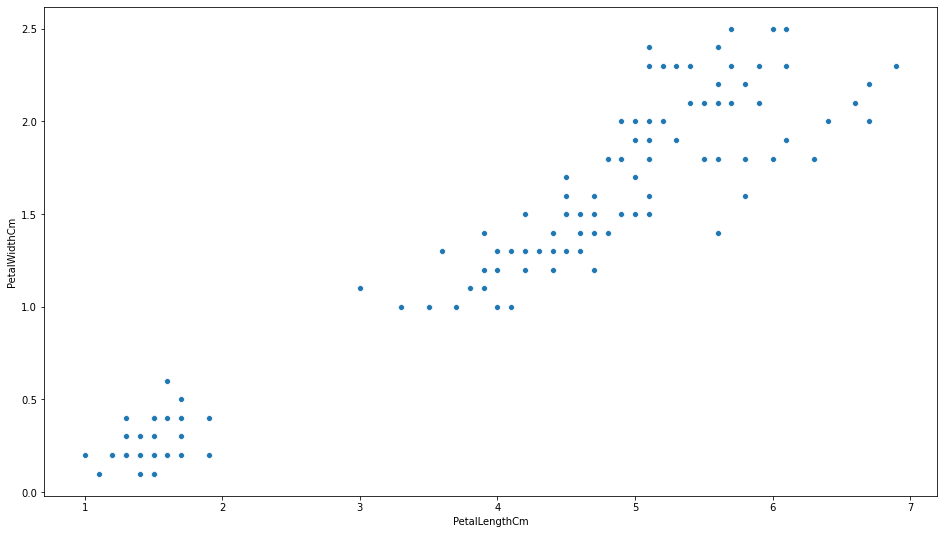

In [11]:
from matplotlib import pyplot as plt
plt.figure(figsize=(16,9))
import seaborn as sns
sns.scatterplot(x="PetalLengthCm",y="PetalWidthCm",data=train_df)

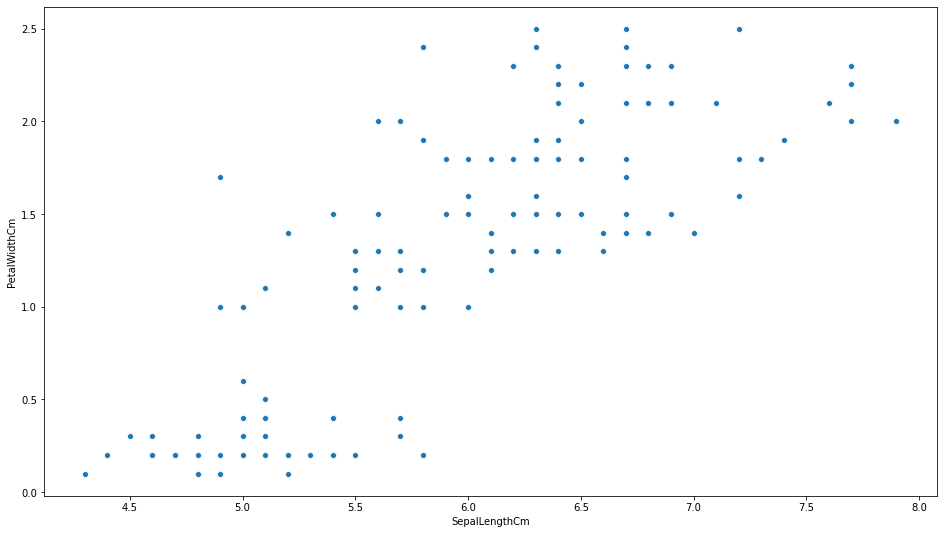

In [12]:
from matplotlib import pyplot as plt
plt.figure(figsize=(16,9))
import seaborn as sns
sns.scatterplot(x="SepalLengthCm",y="PetalWidthCm",data=train_df)

In [15]:
from sklearn import preprocessing 
  

label_encoder = preprocessing.LabelEncoder() 
  

train_df['Species']= label_encoder.fit_transform(train_df['Species']) 
  
train_df['Species'].unique()

array([0, 1, 2])

In [17]:
target=train_df["Species"]
del train_df["Species"]

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train,X_test,y_train,y_test=train_test_split(train_df,target,random_state=0)


In [23]:
X_train

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
61,62,5.9,3.0,4.2,1.5
92,93,5.8,2.6,4.0,1.2
112,113,6.8,3.0,5.5,2.1
2,3,4.7,3.2,1.3,0.2
141,142,6.9,3.1,5.1,2.3
...,...,...,...,...,...
9,10,4.9,3.1,1.5,0.1
103,104,6.3,2.9,5.6,1.8
67,68,5.8,2.7,4.1,1.0
117,118,7.7,3.8,6.7,2.2


In [24]:
X_test

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
114,115,5.8,2.8,5.1,2.4
62,63,6.0,2.2,4.0,1.0
33,34,5.5,4.2,1.4,0.2
107,108,7.3,2.9,6.3,1.8
7,8,5.0,3.4,1.5,0.2
100,101,6.3,3.3,6.0,2.5
40,41,5.0,3.5,1.3,0.3
86,87,6.7,3.1,4.7,1.5
76,77,6.8,2.8,4.8,1.4
71,72,6.1,2.8,4.0,1.3


In [21]:
reg = LogisticRegression()
reg.fit(X_train,y_train)


/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:764: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)


LogisticRegression()

In [22]:
print(reg.score(X_test,y_test)*100)
print(reg.score(X_train,y_train)*100)


100.0
100.0
